# Assignment: K-Nearest Neighbors

Nama    : Faris Akmal Soehartono

NRP     : 3124600101

Kelas   : 3 D4 IT D

Import library

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### 1. Load Dataset

Membaca isi dataset

In [2]:
dataset = pd.read_csv("breast_cancer.csv")

dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Mengecek ukuran dataset

In [3]:
dataset.shape

(569, 33)

Mengubah diagnosisi `M` (malignant) dan `B` (benign) menjadi angka

In [4]:
dataset["diagnosis"] = dataset["diagnosis"].map({
    "M": 1,
    "B": 0
})

Kolom `id` tidak digunakan sebagai fitur karena hanya merupakan identitas sampel

Kolom `Unnamed: 32` juga tidak memiliki data sehingga dapat dihapus

In [5]:
dataset = dataset.drop(columns=["Unnamed: 32", "id"])

Menampilkan `train_data` dan `train_label`

In [6]:
features = dataset.drop(columns=["diagnosis"])
label = dataset["diagnosis"]

print("Train Data:")
display(features.head())

print("Train Label:")
display(label.head())

Train Data:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Train Label:


0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

### 2. Simple EDA

Informasi Dataset

In [7]:
print("\nInformasi dataset")
print(dataset.info())

print("\nDescribe")
print(dataset.describe())


Informasi dataset
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se           

Cek missing values

In [8]:
print("Missing Values")
print(dataset.isnull().sum())

Missing Values
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


Distribusi class

In [9]:
print("Distribusi Class")
print(dataset["diagnosis"].value_counts())

print("\nPersentase Class:")
print(dataset["diagnosis"].value_counts(normalize=True) * 100)

Distribusi Class
diagnosis
0    357
1    212
Name: count, dtype: int64

Persentase Class:
diagnosis
0    62.741652
1    37.258348
Name: proportion, dtype: float64


Cek data duplikat

In [10]:
print("\nJumlah data duplikat:", dataset.duplicated().sum())


Jumlah data duplikat: 0


### 3. Split Data

Split data 80 : 20 untuk data train dan test

In [11]:
features_train, features_test, label_train, label_test = train_test_split(
    features,
    label,
    test_size=0.2,
    random_state=42,
    stratify=label
)

print("Jumlah data training:", features_train.shape[0])
print("Jumlah data testing :", features_test.shape[0])

Jumlah data training: 455
Jumlah data testing : 114


### 4. KNN Tanpa Normalisasi

Mencoba k=1, k=3, dan k=5

In [12]:
k_values = [1, 3, 5]

results_without_scaling = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(features_train, label_train)
    label_pred = model.predict(features_test)
    accuracy = accuracy_score(label_test, label_pred)
    results_without_scaling.append({
        "k": k,
        "accuracy": accuracy
    })

results_without_scaling_df = pd.DataFrame(results_without_scaling)

print("\nKNN tanpa normalisasi:")
print(results_without_scaling_df)


KNN tanpa normalisasi:
   k  accuracy
0  1  0.894737
1  3  0.921053
2  5  0.912281


K terbaik untuk data tanpa normalisasi

In [13]:
best_without_scaling = results_without_scaling_df.loc[
    results_without_scaling_df["accuracy"].idxmax()
]

print("\nK terbaik tanpa normalisasi:")
print("k =", int(best_without_scaling["k"]))
print("Accuracy =", best_without_scaling["accuracy"])


K terbaik tanpa normalisasi:
k = 3
Accuracy = 0.9210526315789473


### 5. KNN dengan Normalisasi

Mencoba k=1, k=3, dan k=5

In [14]:
scaler = MinMaxScaler()
features_train_scaled = scaler.fit_transform(features_train)
features_test_scaled = scaler.transform(features_test)

results_with_scaling = []

for k in [1, 3, 5]:

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(features_train_scaled, label_train)

    label_pred = model.predict(features_test_scaled)

    accuracy = accuracy_score(label_test, label_pred)

    results_with_scaling.append({
        "k": k,
        "accuracy": accuracy
    })


results_with_scaling_df = pd.DataFrame(
    results_with_scaling
)

print("\nKNN dengan MinMaxScaler:")
print(results_with_scaling_df)


KNN dengan MinMaxScaler:
   k  accuracy
0  1  0.929825
1  3  0.956140
2  5  0.956140


K terbaik dengan MinMaxScaler

In [15]:
best_with_scaling = results_with_scaling_df.loc[
    results_with_scaling_df["accuracy"].idxmax()
]

print("\nK terbaik dengan MinMaxScaler:")
print("k =", int(best_with_scaling["k"]))
print("Accuracy =", best_with_scaling["accuracy"])


K terbaik dengan MinMaxScaler:
k = 3
Accuracy = 0.956140350877193


### 6. Perbandingan Model Dengan dan Tanpa Normalisasi

Membandingkan model

In [16]:
comparison = pd.DataFrame({
    "k": k_values,
    "Tanpa Normalisasi": results_without_scaling_df["accuracy"],
    "Dengan MinMaxScaler": results_with_scaling_df["accuracy"]
})

print("Perbandingan Hasil:")
print(comparison)

Perbandingan Hasil:
   k  Tanpa Normalisasi  Dengan MinMaxScaler
0  1           0.894737             0.929825
1  3           0.921053             0.956140
2  5           0.912281             0.956140


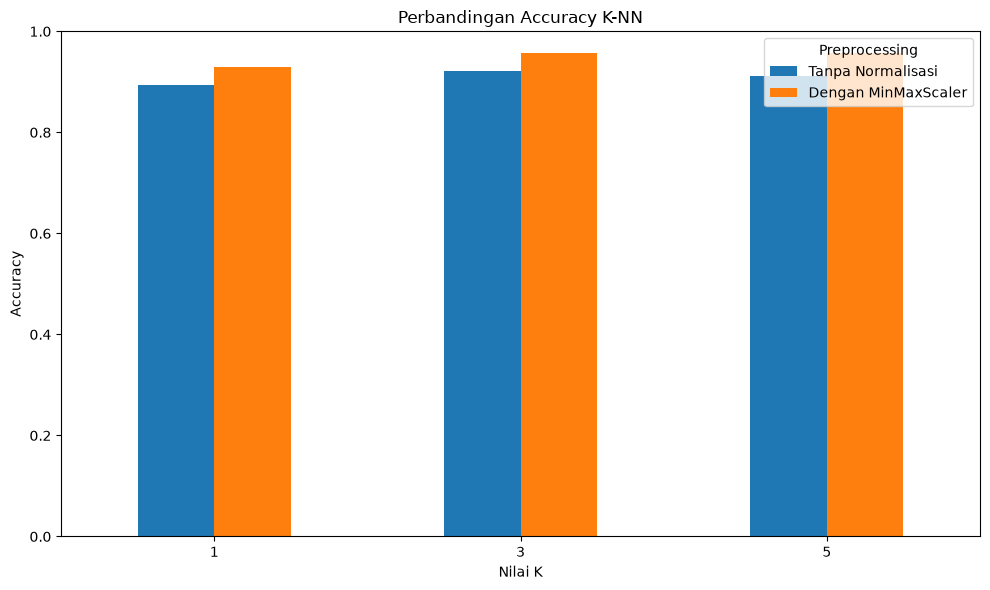

In [17]:
comparison.set_index("k").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Perbandingan Accuracy K-NN")
plt.xlabel("Nilai K")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Preprocessing")
plt.tight_layout()
plt.show()

Model terbaik

In [18]:
best_without = best_without_scaling["accuracy"]
best_with = best_with_scaling["accuracy"]

if best_with > best_without:
    best_k = int(best_with_scaling["k"])
    best_scaler = True
    best_accuracy = best_with
else:
    best_k = int(best_without_scaling["k"])
    best_scaler = False
    best_accuracy = best_without

print("Model Terbaik:")
print("k:", best_k)
print("Menggunakan normalisasi:", best_scaler)
print("Akurasi:", best_accuracy)

Model Terbaik:
k: 3
Menggunakan normalisasi: True
Akurasi: 0.956140350877193


### 7. Testing Single Input

Mengambil satu data dari test set untuk simulasi single input:

In [19]:
single_input = [[
    17.99, 10.38, 122.8, 1001, 0.1184,
    0.2776, 0.3001, 0.1471, 0.2419, 0.07871,
    1.095, 0.9053, 8.589, 153.4, 0.006399,
    0.04904, 0.05373, 0.01587, 0.03003, 0.006193,
    25.38, 17.33, 184.6, 2019, 0.1622,
    0.6656, 0.7119, 0.2654, 0.4601, 0.1189
]]

single_input = pd.DataFrame(
    single_input,
    columns=features_train.columns
)

Menggunakan Model Terbaik

In [20]:
best_model = KNeighborsClassifier(n_neighbors=best_k)

if best_scaler:
    best_model.fit(features_train_scaled, label_train)
    single_input_scaled = scaler.transform(single_input)
    prediction = best_model.predict(single_input_scaled)
else:
    best_model.fit(features_train, label_train)
    prediction = best_model.predict(single_input)

if prediction[0] == 1:
    print("\nHasil prediksi: Malignant (M)")
else:
    print("\nHasil prediksi: Benign (B)")


Hasil prediksi: Malignant (M)


### 8. Kesimpulan

Berdasarkan percobaan yang telah dilakukan pada dataset Breast Cancer, algoritma K-Nearest Neighbor (KNN) diuji menggunakan nilai k=1, k=3, dan k=5, baik tanpa normalisasi maupun dengan normalisasi menggunakan MinMaxScaler. Hasil pengujian menunjukkan bahwa model terbaik diperoleh dengan menggunakan MinMaxScaler dan nilai k=3 karena menghasilkan akurasi tertinggi dibandingkan percobaan lainnya.

Normalisasi menggunakan MinMaxScaler membantu meratakan skala setiap fitur sehingga perhitungan jarak pada algoritma KNN dapat dilakukan dengan lebih baik karena KNN menggunakan jarak data dalam menentukan class.

Selanjutnya, model terbaik digunakan untuk melakukan pengujian menggunakan satu data sebagai single input. Hasil pengujian menunjukkan bahwa data tersebut diprediksi sebagai Benign (B) atau jinak.